# Komlós Conjecture — ShinkaEvolve Launcher

**Task**: Find an n×n matrix A of unit-column-norm vectors that maximises the minimum discrepancy  
$$\min_{x \in \{-1,+1\}^n} \|Ax\|_\infty$$
**Objective**: higher discrepancy = harder instance for the Komlós conjecture (n=9 for evaluation)

### Before getting started

Make sure that you've already completed the following.

-   Created and activated a virtual environment where ShinkaEvolve is installed.

-   Added a `.env` file with your OpenRouter API key to the root of this project.

Please see `README.md` at the root of this project for instructions on how to do if you've not already completed these steps! Finally,

-   If you are using Jupyterlab to edit this notebook in your web browser, make sure you've started your Jupyter server in the virtual environment

-   If you are editing this notebook in VSCode, make sure to select the Python kernel associated with the environment that you've created. It should say `Tutorial_Shinka (<version>)` with a Python executable located at `.venv/bin/python`.

## 1. Check imports

In [1]:
import sys
import logging
import warnings
import dotenv
import os
from pathlib import Path

# Suppress third-party warnings before importing shinka
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Check if ShinkaEvolve is importable
try:
    import shinka
except ImportError:
    print("shinka not found, make sure to open this notebook with the ShinkaEvolve environment active")

# Derive the venv activate script from the current Python interpreter.
# This works regardless of where the venv or the experiment folder lives.
activate_path = str(Path(sys.executable).parent / "activate")
print(f"activate_path  : {activate_path}")

# Find and load the .env file (for OPENROUTER_API_KEY)
env_path = dotenv.find_dotenv()
assert env_path, ".env not found, please add it to the root of this project."
dotenv.load_dotenv()

if os.environ.get("OPENROUTER_API_KEY"):
    print("OPENROUTER_API_KEY: OK")
else:
    print("WARNING: OPENROUTER_API_KEY not set — add it to .env file")

# Suppress the "Waiting for evaluation slot" message, which fires every 0.5s
class _SuppressWaitingFilter(logging.Filter):
    def filter(self, record):
        return "Waiting for evaluation slot" not in record.getMessage()

logging.getLogger("shinka.core.async_runner").addFilter(_SuppressWaitingFilter())

activate_path  : /Users/mp2557/Documents/Research/ShinkaEvolve/.venv/bin/activate
OPENROUTER_API_KEY: OK


## 2. Test the evaluator

Verify `evaluate.py` runs correctly on `initial_program.py` before launching evolution.

In [2]:
import evaluate
import initial_program

# ── Evaluation parameters (forwarded to evaluate.py via environment variables) ──
n = 9            # instance size: matrix will be n×n

# Test the initial program for Komlós
output = initial_program.run_komlos(n=n)

# Check if the program outputs a valid result
valid, msg = evaluate.validate_fn(output)

# Assert check
assert valid, f"Smoke test failed: {msg}"
_, cost, _ = output
print(f"Smoke test: PASSED  (n={n}, min_discrepancy={cost:.6f})")

Smoke test: PASSED  (n=9, min_discrepancy=0.740314)


## 3. Configure Shinka evolution

In [3]:
import os
import datetime as dt
from shinka.core import ShinkaEvolveRunner, EvolutionConfig
from shinka.database import DatabaseConfig
from shinka.launch import LocalJobConfig

# ── Evaluation parameters (forwarded to evaluate.py via environment variables) ──
n = 9            # instance size: matrix will be n×n
NUM_RUNS = 6     # evaluation runs per candidate
NUM_WORKERS = 3  # parallel workers for evaluation runs

os.environ["N"] = str(n)
os.environ["NUM_RUNS"] = str(NUM_RUNS)
os.environ["NUM_WORKERS"] = str(NUM_WORKERS)

# ── Task-specific parameters ──
TASK_SYS_MSG = """
You are an expert mathematician specializing in discrepancy theory and linear algebra.

You want to construct hard instances for the Komlos conjecture by generating Python code. In other words, you want to find a matrix A of size n x n such that
the minimum discrepancy of its columns (i.e. the largest entry of the vector Ax - in absolute value - is minimized) is as large as possible.

Key directions to explore:
1. Try looking for matrices with explicit structure that prevents cancellations of columns
2. Try different structured matrices (Hadamard, conference, Toeplitz, etc.)  as starting blocks for the exploration.
3. You can use the scipy package to find vectors with larger discrepancy (e.g. Nelder-Mead, L-BFGS, etc. )
4. You can use other optimization heuristics such as simulated annealing or evolutionary algorithms in your program, and you can combine different heuristics
5. Looking for structured explicit constructions and use that as a starting point for the optimization heuristics could be very useful

Be creative and try to find a new solution better than the best known result. I believe in your ability and I am excited to see what you can do."""

experiment_name = "komlos_" + dt.datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = "results/" + experiment_name
print(f"Results dir    : {RESULTS_DIR}")

# ── EvoConfig parameters ──

LLM_MODELS = ["openrouter/anthropic/claude-haiku-4-5",
              "openrouter/openai/gpt-5.1-codex-mini",
              "openrouter/openai/gpt-5.4-mini",
              "openrouter/openai/o4-mini",
              "openrouter/openai/gpt-5-nano",
              "openrouter/google/gemini-3.1-flash-lite-preview",
              # "openrouter/google/gemini-3.1-pro-preview",  # expensive model
              "openrouter/qwen/qwen3-coder-next"]

NUM_GENERATIONS = 20

# ── Other LLM parameters ── not too important for now but must be overwritten for OpenRouter keys (default is OpenAI)

META_LLM_MODELS = ["openrouter/openai/o4-mini"]
NOVELTY_LLM_MODELS = ["openrouter/openai/o4-mini"]
EMBEDDING_MODEL = "openrouter/openai/text-embedding-3-small"


# ── DBConfig parameters ──

NUM_ISLANDS = 3

###

evo_config = EvolutionConfig(task_sys_msg=TASK_SYS_MSG,
                            results_dir=RESULTS_DIR,
                            init_program_path="initial_program.py",
                            llm_models=LLM_MODELS,
                            num_generations=NUM_GENERATIONS,
                            meta_llm_models=META_LLM_MODELS,
                            novelty_llm_models=NOVELTY_LLM_MODELS,
                            embedding_model=EMBEDDING_MODEL)

db_config   = DatabaseConfig(num_islands=NUM_ISLANDS)

# activate_script ensures the subprocess uses the venv's Python (where shinka is installed)
job_config = LocalJobConfig(eval_program_path="evaluate.py",
                            activate_script=activate_path,
                            time="0:06:00")

Results dir    : results/komlos_20260420_093050


## 4. Launch evolution

In [4]:
from time import perf_counter

MAX_PROPOSAL_JOBS = 3
MAX_EVALUATION_JOBS = 2

runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    max_proposal_jobs=MAX_PROPOSAL_JOBS,
    max_evaluation_jobs=MAX_EVALUATION_JOBS,
    verbose=True,
)

tic = perf_counter()
await runner.run_async()
toc = perf_counter()

print(f"Evolution completed in {toc - tic:.1f} s")
print(f"Results saved to: {runner.results_dir}")

  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@          @     @           @  @
                      @            @          @ 

2026-04-20 09:30:56 - shinka.core.async_runner - INFO - 🖥️  System resources detected:

2026-04-20 09:30:56 - shinka.core.async_runner - INFO -    • CPU cores: 8

2026-04-20 09:30:56 - shinka.core.async_runner - INFO -    • Memory: 16.0 GB

2026-04-20 09:30:56 - shinka.core.async_runner - INFO - 🔧 Concurrency settings:

...

2026-04-20 09:35:18 - shinka.llm.llm - INFO - ==> QUERYING: ['openrouter/openai/o4-mini', '0.75', '4096']

2026-04-20 09:35:19 - httpx - INFO - HTTP Request: POST https://openrouter.ai/api/v1/responses "HTTP/1.1 200 OK"

2026-04-20 09:35:30 - shinka.database.async_dbase - INFO - 🔧 Closing async database with monitoring...

2026-04-20 09:35:30 - shinka.database.async_dbase - INFO - Async database closed

CancelledError: 

## 5. Web UI for evolution visualization - run this while evolution is running or after it is complete

In a separate Terminal, activate the ShinkaEvolve virtual environment and run the following command from the directory of this notebook:

`shinka_visualize --db results --port 8000 --open`

This will open the WebUI with a lot of information about the evolution.

**Warning**: there is often a bug when launching the Web UI, where the browser tab opens but the database is not loaded. To resolve it, click on `Dashboard` on the top left corner and the list of available databases should appear.

## 6. Inspect results - run this once the evolution is complete

Total program rows: 32
Correct program rows: 32
Total cost: $0.59
Avg cost per program: $0.02
Loaded 32 programs from database.
GraphViz not available, using hierarchical layout


/Users/mp2557/Documents/Research/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/mp2557/Documents/Research/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


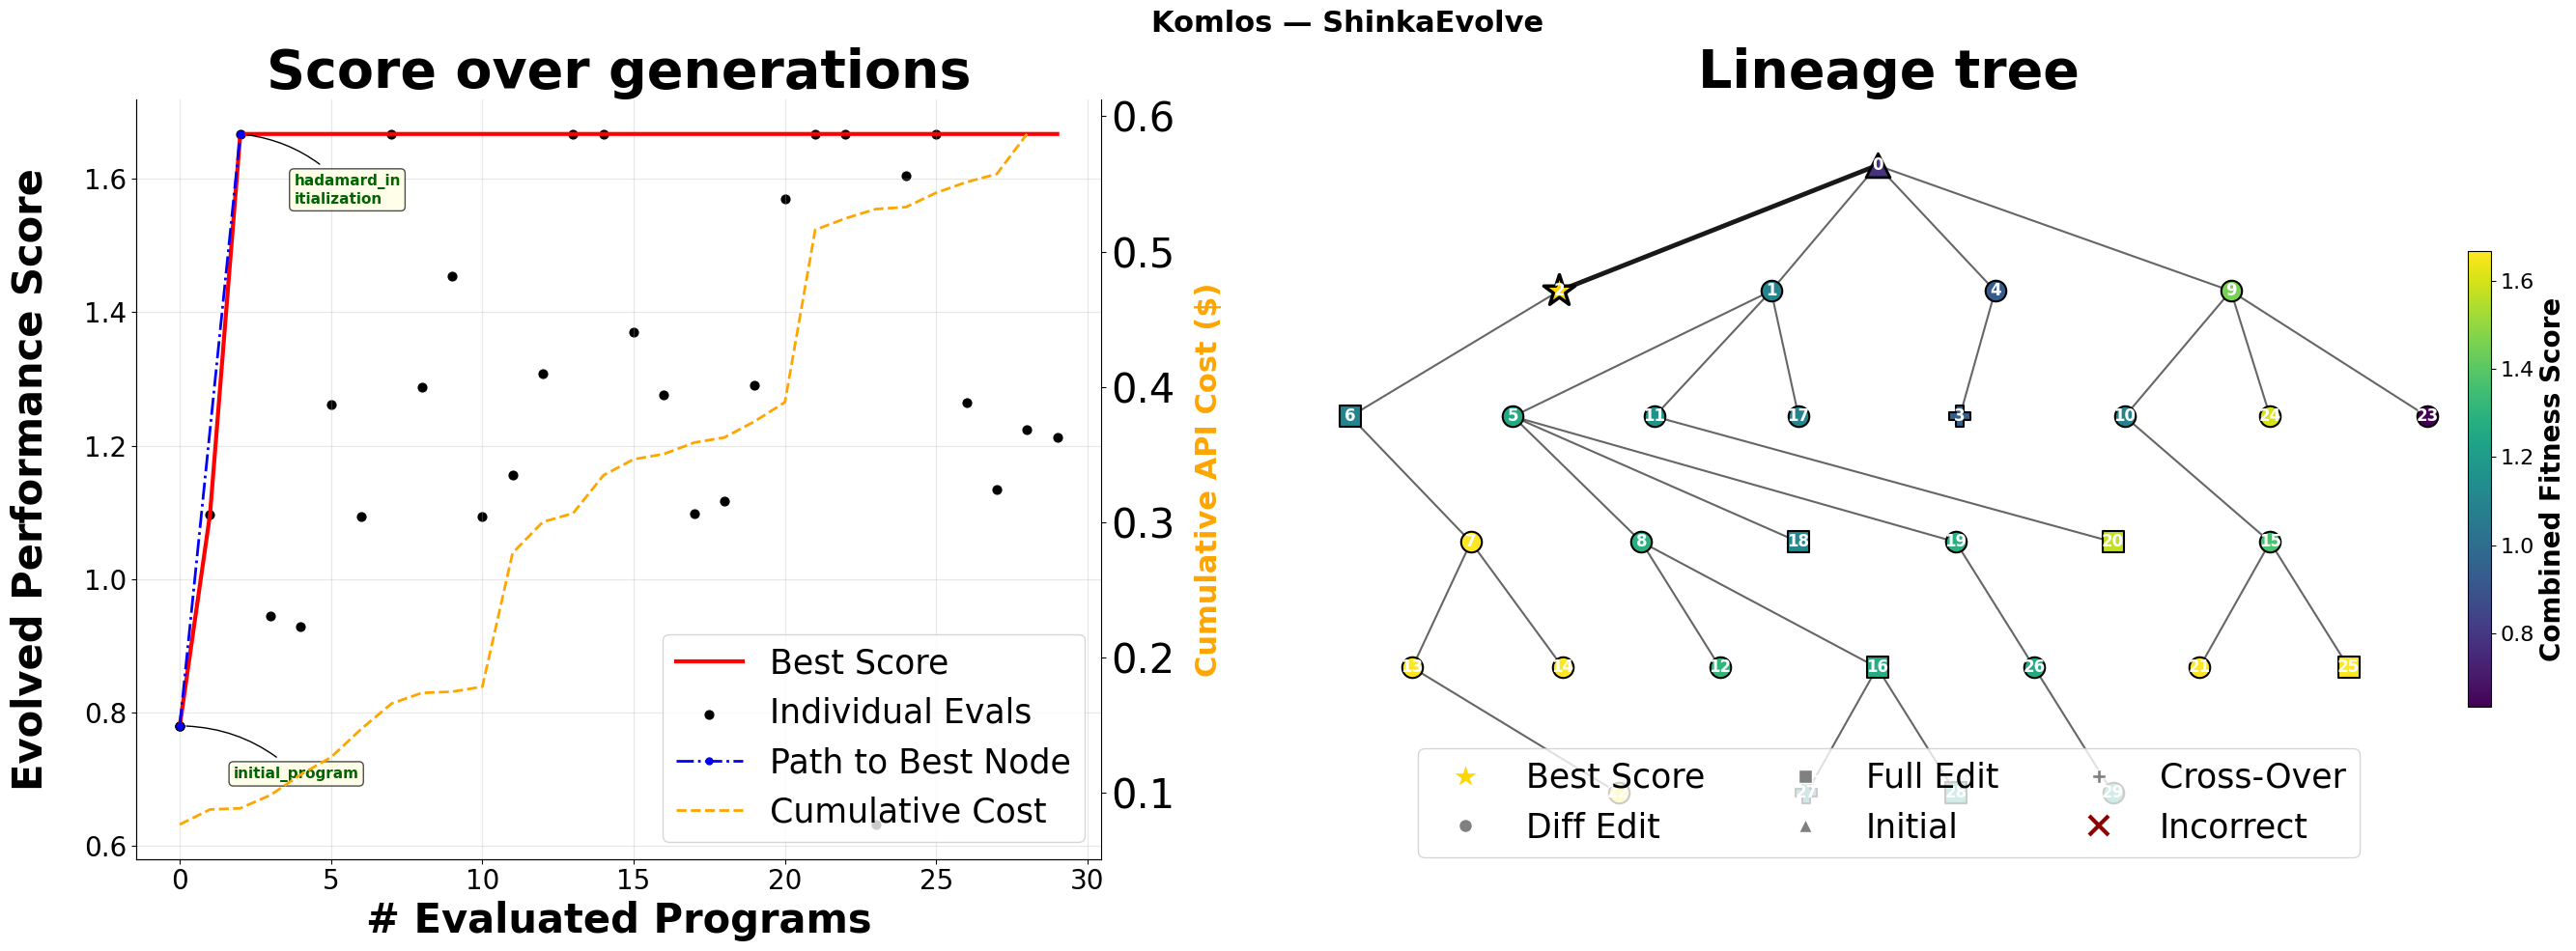

In [6]:
import matplotlib.pyplot as plt
from shinka.utils import load_programs_to_df
from shinka.plots import plot_lineage_tree, plot_evals_performance

results_root = Path("results") / experiment_name
# results_root = Path(runner.results_dir)

db_candidates = [
    results_root / "programs.sqlite"
]
db_path = next((p for p in db_candidates if p.exists()), None)
assert db_path is not None, "Could not find programs.sqlite"

df = load_programs_to_df(str(db_path))
print(f"Loaded {len(df)} programs from database.")

fig, axs = plt.subplots(1, 2, figsize=(28, 10), gridspec_kw={"width_ratios": [1, 1.5]})
fig.suptitle("Komlos — ShinkaEvolve", fontsize=22, weight="bold")

plot_evals_performance(df, "Score over generations", fig, axs[0])
plot_lineage_tree(df, "Lineage tree", fig, axs[1])

plt.tight_layout()
plt.show()

## 7. Load and inspect the best solution

In [7]:
import importlib.util
import numpy as np

best_program = results_root / "best" / "main.py"
assert best_program.exists(), f"Best program not found at {best_program}"

spec = importlib.util.spec_from_file_location("best_program", best_program)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

vectors, cost, signs = mod.run_komlos(n=9)
print(f"Matrix shape  : {vectors.shape}")
print(f"Min discrepancy (best): {cost:.6f}")
print(f"Best signs    : {signs.tolist()}")
print(f"Column norms  : min={np.linalg.norm(vectors, axis=0).min():.6f}, max={np.linalg.norm(vectors, axis=0).max():.6f}")

Matrix shape  : (9, 9)
Min discrepancy (best): 1.666667
Best signs    : [-1, -1, -1, -1, -1, 1, -1, 1, -1]
Column norms  : min=1.000000, max=1.000000


---

# Running a more extensive experiment

In [ ]:
# ── Evaluation parameters (forwarded to evaluate.py via environment variables) ──
n = 9            # instance size: matrix will be n×n
NUM_RUNS = 6     # evaluation runs per candidate
NUM_WORKERS = 3  # parallel workers for evaluation runs

os.environ["N"] = str(n)
os.environ["NUM_RUNS"] = str(NUM_RUNS)
os.environ["NUM_WORKERS"] = str(NUM_WORKERS)

# ── Task-specific parameters ──
TASK_SYS_MSG = """
You are an expert mathematician specializing in discrepancy theory and linear algebra.

You want to construct hard instances for the Komlos conjecture by generating Python code. In other words, you want to find a matrix A of size n x n such that
the minimum discrepancy of its columns (i.e. the largest entry of the vector Ax - in absolute value - is minimized) is as large as possible.

Key directions to explore:
1. Try looking for matrices with explicit structure that prevents cancellations of columns
2. Try different structured matrices (Hadamard, conference, Toeplitz, etc.)  as starting blocks for the exploration.
3. You can use the scipy package to find vectors with larger discrepancy (e.g. Nelder-Mead, L-BFGS, etc. )
4. You can use other optimization heuristics such as simulated annealing or evolutionary algorithms in your program, and you can combine different heuristics
5. Looking for structured explicit constructions and use that as a starting point for the optimization heuristics could be very useful

Be creative and try to find a new solution better than the best known result. I believe in your ability and I am excited to see what you can do."""

experiment_name = "komlos_" + dt.datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = "results/" + experiment_name
print(f"Results dir    : {RESULTS_DIR}")

# ── EvoConfig parameters ──

# Don't use Gemini 3.1 Pro!!
LLM_MODELS = ["openrouter/anthropic/claude-haiku-4-5",
              "openrouter/openai/gpt-5.3-codex",
              "openrouter/openai/gpt-5.4-mini",
              "openrouter/openai/o4-mini",
              "openrouter/openai/gpt-5-nano",
              "openrouter/google/gemini-3.1-flash-lite-preview",
              # "openrouter/google/gemini-3-pro-preview",  # expensive model
              "openrouter/qwen/qwen3-coder-next"]

NUM_GENERATIONS = 100

# ── Other LLM parameters ── not too important for now but must be overwritten for OpenRouter keys (default is OpenAI)

META_LLM_MODELS = ["openrouter/openai/o4-mini"]
NOVELTY_LLM_MODELS = ["openrouter/openai/o4-mini"]
EMBEDDING_MODEL = "openrouter/openai/text-embedding-3-small"


# ── DBConfig parameters ──

NUM_ISLANDS = 4
ARCHIVE_SIZE = 40

###

evo_config = EvolutionConfig(task_sys_msg=TASK_SYS_MSG,
                            results_dir=RESULTS_DIR,
                            init_program_path="initial_program.py",
                            llm_models=LLM_MODELS,
                            num_generations=NUM_GENERATIONS,
                            meta_llm_models=META_LLM_MODELS,
                            novelty_llm_models=NOVELTY_LLM_MODELS,
                            embedding_model=EMBEDDING_MODEL)

db_config   = DatabaseConfig(num_islands=NUM_ISLANDS)

# activate_script ensures the subprocess uses the venv's Python (where shinka is installed)
job_config = LocalJobConfig(eval_program_path="evaluate.py",
                            activate_script=activate_path,
                            time="0:06:00")

MAX_PROPOSAL_JOBS = 3
MAX_EVALUATION_JOBS = 2

runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    max_proposal_jobs=MAX_PROPOSAL_JOBS,
    max_evaluation_jobs=MAX_EVALUATION_JOBS,
    verbose=True,
)

tic = perf_counter()
await runner.run_async()
toc = perf_counter()

print(f"Evolution completed in {toc - tic:.1f} s")
print(f"Results saved to: {runner.results_dir}")